In [80]:
LINKEDIN_QUERY_PROMPT = """
You are a professional LinkedIn Talent Sourcing Assistant.

Your task is to generate precise and effective LinkedIn Boolean search queries based on hiring requirements.

----------------------------------------
User Input:
{user_input}
----------------------------------------

Instructions:

1. Hiring / Recruitment Queries:
If the user input is related to hiring, recruitment, job roles, or candidate sourcing:
- Extract the following (if available):
  • Job role / title
  • Skills / technologies
  • Experience level (optional)
  • Location (optional)
- Construct a clean LinkedIn Boolean search query
- Use:
  • OR for similar job titles
  • AND to combine different attributes (role, skills, location)
- Keep the query concise and optimized for LinkedIn search
- Output ONLY the Boolean query (no explanation, no extra text)

2. Greetings / Casual Conversation:
If the user input is a greeting or casual message:
- Respond politely and professionally
- Example:
  "Hello! I’m a LinkedIn sourcing assistant. How can I help you with hiring today?"

3. Out-of-Scope Queries:
If the user input is unrelated to recruitment or candidate sourcing:
- Respond professionally and restrict scope
- Example:
  "I am designed specifically to assist with recruitment and LinkedIn candidate sourcing. Please share hiring-related requirements so I can assist you."

4. General Questions About Recruitment:
If the user asks general questions (e.g., "Can you help me recruit candidates?"):
- Respond politely and guide them to provide specific hiring requirements
- Example:
  "Yes, I can help with sourcing candidates. Please provide details such as role, skills, and location."

----------------------------------------

Important Rules:

- Do NOT generate Boolean queries for non-hiring inputs
- Do NOT include explanations when generating queries
- Always keep responses concise and professional
- Prefer standard job title variations using OR
- Avoid unnecessary keywords that reduce search precision
- Ensure output is directly usable in LinkedIn search
- You do not need to generate
----------------------------------------

Examples:

Input: Looking for Java developers with Spring Boot in Bangalore  
Output: ("Java Developer" OR "Java Engineer") AND ("Spring Boot") AND ("Bangalore")

Input: Need frontend engineers skilled in React and TypeScript  
Output: ("Frontend Developer" OR "Frontend Engineer") AND ("React") AND ("TypeScript")

Input: Hiring data scientists with Python, ML experience in India  
Output: ("Data Scientist") AND ("Python") AND ("Machine Learning" OR "ML") AND ("India")

Input: Looking for blockchain developers with Solidity and Web3  
Output: ("Blockchain Developer") AND ("Solidity") AND ("Web3")
"""

In [81]:
INTENT_CLASSIFIER_PROMPT = """
You are an Intent Classification Assistant for a LinkedIn Talent Sourcing system.

Your task is to analyze the user input and classify the intent accurately.

----------------------------------------
User Input:
{user_input}
----------------------------------------

Instructions:

Classify the user input into ONE of the following intents:

1. "search_candidates"
   - User is asking to find, hire, recruit, or source candidates
   - Mentions roles, skills, experience, or location
   - Examples:
     • "Need Java developers with Spring Boot"
     • "Looking for frontend engineers in Bangalore"
     • "Hire data scientists with Python"

2. "greeting"
   - User is greeting or starting casual conversation
   - Examples:
     • "Hi"
     • "Hello"
     • "Hey there"

3. "general_recruitment_query"
   - User is asking general questions about hiring/recruitment
   - Examples:
     • "Can you help me recruit candidates?"
     • "How do I hire developers?"

4. "out_of_scope"
   - Anything unrelated to recruitment or candidate sourcing
   - Examples:
     • "Tell me a joke"
     • "What is blockchain?"

Rules:
- Always return exactly one intent
- Be strict in classification (avoid guessing search intent unless clearly hiring-related)

----------------------------------------

Examples:

Input: Looking for Java developers with Spring Boot  
Output: search_candidates

Input: Hi  
Output:  greeting

Input: Can you help me recruit candidates?  
Output: general_recruitment_query

Input: What is machine learning?  
Output: out_of_scope
"""

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, List
import json
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from typing_extensions import TypedDict

from IPython.display import Image,display

import os

import requests

In [83]:
class Context(TypedDict):
    """Context parameters for the agent.

    Set these when creating assistants OR when invoking the graph.
    See: https://langchain-ai.github.io/langgraph/cloud/how-tos/configuration_cloud/
    """

    my_configurable_param: str

class State(TypedDict):
    """Input state for the agent.

    Defines the initial structure of incoming data.
    See: https://langchain-ai.github.io/langgraph/concepts/low_level/#state
    """
    user_prompt: str
    user_prompt_intent: str
    query_response: str
    linkedin_results: List[str]

In [84]:
def classify_user_prompt_intent(state: State, runtime: Runtime[Context]) -> Dict[str, Any]:
    LLM_BASE_URL = os.getenv("LLM_BASE_URL")    
    prompt = INTENT_CLASSIFIER_PROMPT.format(
        user_input=state.get('user_prompt')
    )
    
    data = {
    "model": "qwen2.5",
    "prompt": prompt
    }
        
    response = requests.post(
        LLM_BASE_URL+"/api/generate", 
        json=data, 
        stream=True
    )
        
    full_response = ""
    
    for line in response.iter_lines():
        if line:
            chunk = json.loads(line)
            full_response += chunk.get("response", "")
    
    print("Response From LLM in[classify_user_prompt_intent]::::::", full_response)
    
    state['user_prompt_intent'] = full_response
    
    return state

In [ ]:
def build_search_query_linkedin(state: State, runtime: Runtime[Context]) -> Dict[str, Any]:
    """Process input and returns output.

    Can use runtime context to alter behavior.
    """    
    LLM_BASE_URL = os.getenv("LLM_BASE_URL")
    
    prompt = LINKEDIN_QUERY_PROMPT.format(
        user_input=state.get('user_prompt')
    )
    
    data = {
    "model": "qwen2.5",
    "prompt": prompt
    }
        
    response = requests.post(
        LLM_BASE_URL+"/api/generate", 
        json=data, 
        stream=True
    )
        
    full_response = ""
    
    for line in response.iter_lines():
        if line:
            chunk = json.loads(line)
            full_response += chunk.get("response", "")
            print("full_response INSIDE::::::::::::::::::::::;", full_response)
    
    print("FULL RESPONSE OUTSIDE LOOP IS is:::::::::::::::::::::::::", full_response)
    
    state['query_response'] = full_response
    
    return state

In [ ]:
def search_linkedin_profiles(state: State, runtime: Runtime[Context]) -> Dict[str, Any]: 
    base_url =  os.getenv("SERPER_BASE_URL")
    
    endpoint = base_url+"/search"
    
    searchQuery = f'site:linkedin.com/in {state.get("query_response")}'
    
    print("searchQuery::::::::::::", searchQuery)
    
    payload = {
        "q": searchQuery,
        "num": 10
    }

    headers = {
        "X-API-KEY": os.getenv("SERPER_API_KEY"),
        "Content-Type": "application/json"
    }

    response = requests.post(endpoint, json=payload, headers=headers)
    data = response.json()
    
    results = []

    for item in data.get("organic", []):
        link = item.get("link", "")
        
        if "linkedin.com/in" in link:
            results.append({
                "title": item.get("title"),
                "snippet": item.get("snippet"),
                "url": link
            })
    # print("results:::::::::::::::::::::", results)
    if(len(results)):
        state['query_response'] = results
        
    return state


In [96]:
def handle_irrelevant(state: State, runtime: Context[Context]) :  
    state['query_response'] = "I am designed specifically to assist with recruitment and LinkedIn candidate sourcing. Please provide hiring-related requirements."
    
    return state


def handle_greeting(state: State, runtime: Context[Context]) :
    state['query_response'] = "Hi, I am a LinkedIn sourcing assistant. How can I help you with hiring today?"
    
    return state
    
def handle_general_query(state: State):
    state['query_response'] = "I can help you source candidates. Please provide role, skills, and location." 
    
    return state

def handle_general_recruitment_query(state: State):
    state['query_response'] = "I can help you source candidates. Please provide role, skills, and location." 
    
    return state

def handle_out_of_scope(state: State):
    state['query_response'] = "I am designed for recruitment and candidate sourcing. Please share hiring requirements."
    
    return state
    
def route_intent(state: State, runtime: Context[Context]):
    intent = state.get("user_prompt_intent")

    if intent == "search_candidates":
        return "build_search_query_linkedin"
    elif intent == "greeting":
        return "handle_greeting"
    elif intent == "general_recruitment_query":
        return "handle_general_recruitment_query"
    else:
        return "handle_out_of_scope"

In [97]:
graph = (
    StateGraph(State, context_schema=Context)
    # Nodes
    .add_node("classify_user_prompt_intent", classify_user_prompt_intent)
    .add_node("build_search_query_linkedin", build_search_query_linkedin)
    .add_node("handle_greeting", handle_greeting)
    .add_node("handle_general_query", handle_general_query)
    .add_node("handle_out_of_scope", handle_out_of_scope)
    .add_node("handle_general_recruitment_query", handle_general_recruitment_query)
    .add_node("search_linkedin_profiles", search_linkedin_profiles)
    
    #Flow
    .add_edge(START, "classify_user_prompt_intent")
    .add_conditional_edges("classify_user_prompt_intent", route_intent, 
                           {
                               "build_search_query_linkedin": "build_search_query_linkedin",
                                "handle_greeting": "handle_greeting",
                                "handle_general_query": "handle_general_query",
                                "handle_general_recruitment_query": "handle_general_recruitment_query",
                                "handle_out_of_scope": "handle_out_of_scope",
                            })
    .add_edge("build_search_query_linkedin", "search_linkedin_profiles")
    # End all paths
    .add_edge("search_linkedin_profiles", END)
    .add_edge("build_search_query_linkedin", END)
    .add_edge("handle_greeting", END)
    .add_edge("handle_general_query", END)
    .add_edge("handle_out_of_scope", END)
    .add_edge("handle_general_recruitment_query", END)
    # .add_edge(START, "build_search_query_linkedin")
    # .add_edge("build_search_query_linkedin", "search_linkedin_profiles")
    # .add_edge("classify_user_prompt_intent", END)
    
    .compile(name="Talent Sourcing Graph")
)

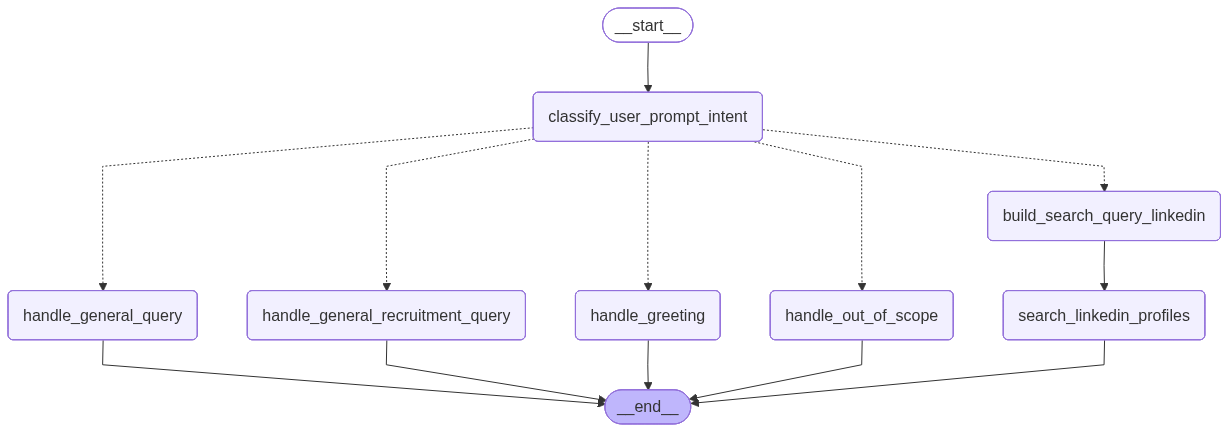

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [113]:
graph.invoke({"user_prompt": "I need AI engineer in Panjim goa with 1+ years of experience"})

Response From LLM in[classify_user_prompt_intent]:::::: search_candidates
full_response INSIDE::::::::::::::::::::::; ("
full_response INSIDE::::::::::::::::::::::; ("AI
full_response INSIDE::::::::::::::::::::::; ("AI Engineer
full_response INSIDE::::::::::::::::::::::; ("AI Engineer")
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+ years
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+ years of
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+ years of experience
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+ years of experience")
full_response INSIDE::::::::::::::::::::::; ("AI Engineer") AND ("1+ years of experience") AND
full_response IN

{'user_prompt': 'I need AI engineer in Panjim goa with 1+ years of experience',
 'user_prompt_intent': 'search_candidates',
 'query_response': '("AI Engineer") AND ("1+ years of experience") AND ("Panjim Goa")'}